In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd
df = pd.read_csv("/content/gopuff_data.csv")

In [4]:
df.head(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
5,low fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.80,81.4618,5.0
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.70,96.0726,5.0
8,Low Fat,FDW20,Fruits and Vegetables,2000,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.75,124.1730,5.0
9,Low Fat,FDX25,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,NaN,181.9292,5.0


In [5]:
df.tail(5)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8518,low fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,reg,FDM58,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


In [6]:
print("Size of Data:" ,df.shape)

Size of Data: (8523, 12)


In [7]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

In [8]:
df.dtypes

,0
Item Fat Content,object
Item Identifier,object
Item Type,object
Outlet Establishment Year,int64
Outlet Identifier,object
Outlet Location Type,object
Outlet Size,object
Outlet Type,object
Item Visibility,float64
Item Weight,float64


In [9]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


In [10]:
df['Item Fat Content'] =df ['Item Fat Content'].replace({'LF': 'Low Fat',
                                                         'low fat': 'Low Fat',
                                                         'reg': 'Regular'
                                                        })

In [11]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat']


In [12]:
# Total Sales
total_sales = df['Sales'].sum()

# Average Sales
avg_sales = df['Sales'].mean()

# Number of Items Sold (no Quantity column, so fallback = count of rows)
no_of_items_sold = df['Sales'].count()

# Average Rating (column name is 'Rating', not 'Ratings')
avg_ratings = df['Rating'].mean()

# Display
print(f"Total sales: ${total_sales:,.0f}")
print(f"Average sales: ${avg_sales:,.0f}")
print(f"Number of items sold: {no_of_items_sold:,.0f}")
print(f"Average rating: {avg_ratings:.2f}")

Total sales: $1,201,681
Average sales: $141
Number of items sold: 8,523
Average rating: 3.97


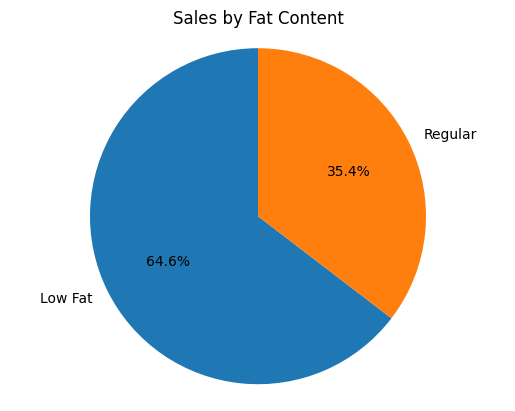

In [13]:
import matplotlib.pyplot as plt

sales_by_fat = df.groupby('Item Fat Content')['Sales'].sum()

plt.pie(
    sales_by_fat,
    labels=sales_by_fat.index,
    autopct='%.1f%%',
    startangle=90
)
plt.title('Sales by Fat Content')
plt.axis('equal')  # Ensures pie chart is a circle
plt.show()

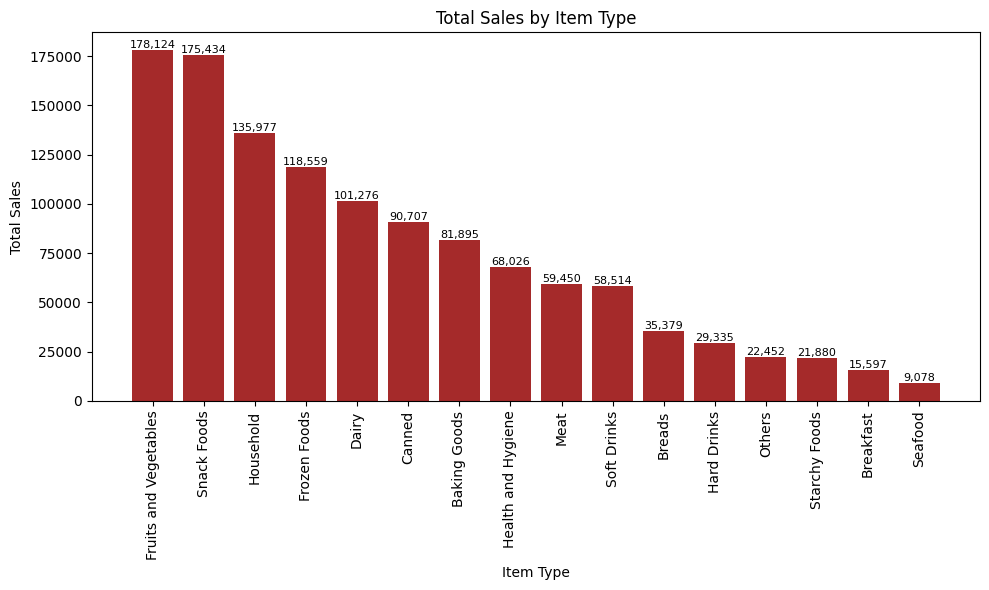

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Group and sort sales by item type
sales_by_type = df.groupby('Item Type')['Sales'].sum().sort_values(ascending=False)

# Set figure size
plt.figure(figsize=(10, 6))

# Create bar chart
bars = plt.bar(sales_by_type.index, sales_by_type.values, color='brown')

# Rotate x-axis labels for readability
plt.xticks(rotation=90)
plt.xlabel('Item Type')
plt.ylabel('Total Sales')
plt.title('Total Sales by Item Type')
# Add value labels on top of each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():,.0f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

# Adjust layout to prevent clipping
plt.tight_layout()
plt.show()


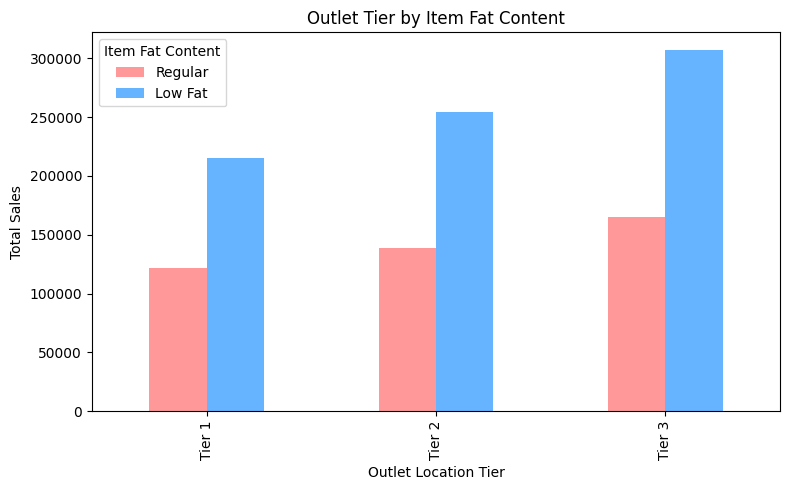

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Group and reshape the data
grouped = df.groupby(['Outlet Location Type', 'Item Fat Content'])['Sales'].sum().unstack()

# Filter only 'Regular' and 'Low Fat' categories
grouped = grouped[['Regular', 'Low Fat']]

# Plot the grouped bar chart
ax = grouped.plot(
    kind='bar',
    figsize=(8, 5),
    title='Outlet Tier by Item Fat Content',
    color=['#FF9999', '#66B3FF']  # Optional: custom colors
)

# Axis labels and legend
plt.xlabel('Outlet Location Tier')
plt.ylabel('Total Sales')
plt.legend(title='Item Fat Content')

# Layout adjustment
plt.tight_layout()
plt.show()

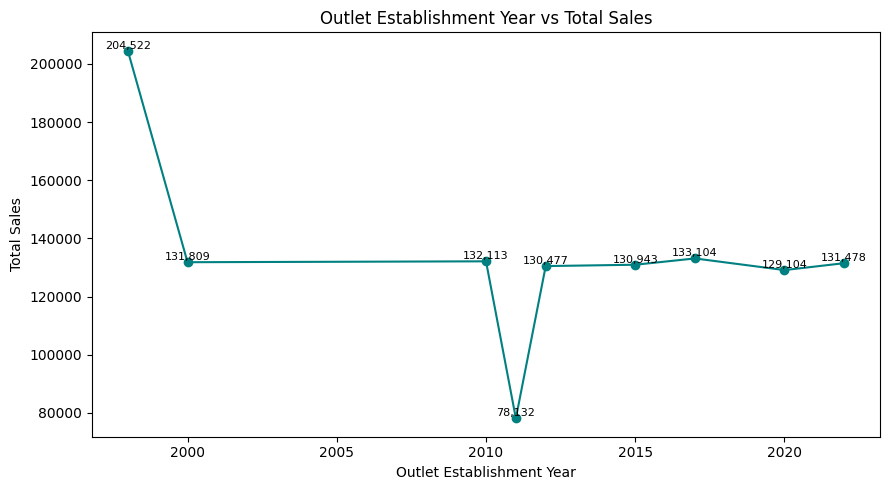

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Line chart: Total Sales by Outlet Establishment Year
sales_by_year = df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()

plt.figure(figsize=(9, 5))
plt.plot(sales_by_year.index, sales_by_year.values, marker='o', linestyle='-', color='teal')
plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Outlet Establishment Year vs Total Sales')

# Add value labels
for x, y in zip(sales_by_year.index, sales_by_year.values):
    plt.text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)


plt.tight_layout()
plt.show()

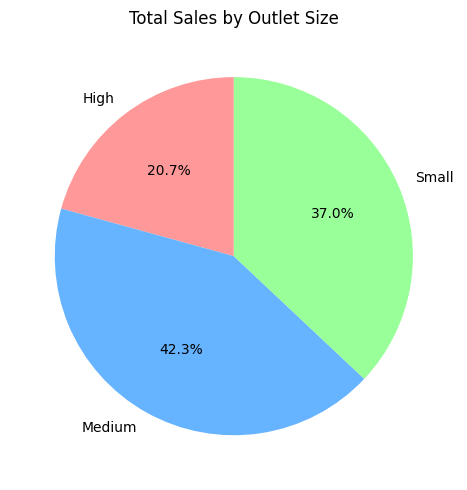

In [17]:
# Pie chart: Total Sales by Outlet Size
sales_by_size = df.groupby('Outlet Size')['Sales'].sum()

plt.figure(figsize=(5, 5))
plt.pie(
    sales_by_size,
    labels=sales_by_size.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#FF9999', '#66B3FF', '#99FF99']  # Optional: custom colors
)
plt.title('Total Sales by Outlet Size')
plt.tight_layout()
plt.show()

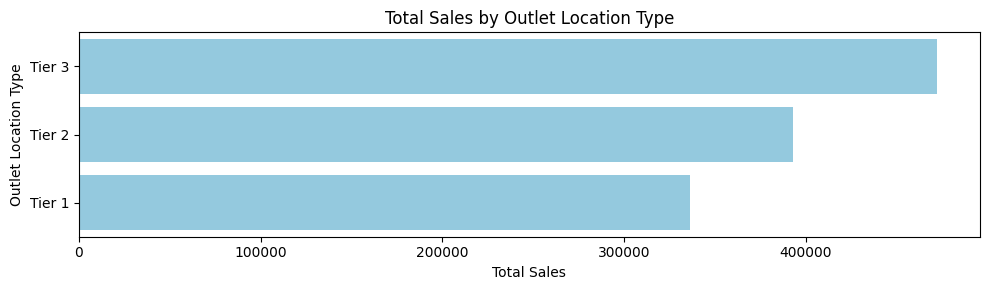

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Group and sort sales by outlet location type
sales_by_location = (
    df.groupby('Outlet Location Type')['Sales']
      .sum()
      .reset_index()
      .sort_values('Sales', ascending=False)
)

# Set figure size
plt.figure(figsize=(10, 3))  # Wide layout, compact height

# Create horizontal bar chart (using color instead of palette to avoid warning)
ax = sns.barplot(
    x='Sales',
    y='Outlet Location Type',
    data=sales_by_location,
    color='skyblue'  # Single color for all bars
)

# Add titles and labels
plt.title('Total Sales by Outlet Location Type')
plt.xlabel('Total Sales')
plt.ylabel('Outlet Location Type')

# Adjust layout to prevent clipping
plt.tight_layout()
plt.show()

In [19]:
df.shape

(8523, 12)

In [20]:
df.dtypes

,0
Item Fat Content,object
Item Identifier,object
Item Type,object
Outlet Establishment Year,int64
Outlet Identifier,object
Outlet Location Type,object
Outlet Size,object
Outlet Type,object
Item Visibility,float64
Item Weight,float64


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [22]:
df.describe()

,Outlet Establishment Year,Item Visibility,Item Weight,Sales,Rating
count,8523.000000,8523.000000,7060.000000,8523.000000,8523.000000
mean,2010.831867,0.066132,12.857645,140.992782,3.965857
std,8.371760,0.051598,4.643456,62.275067,0.605651
min,1998.000000,0.000000,4.555000,31.290000,1.000000
25%,2000.000000,0.026989,8.773750,93.826500,4.000000
50%,2012.000000,0.053931,12.600000,143.012800,4.000000
75%,2017.000000,0.094585,16.850000,185.643700,4.200000
max,2022.000000,0.328391,21.350000,266.888400,5.000000


In [23]:
df.isnull().sum()

,0
Item Fat Content,0
Item Identifier,0
Item Type,0
Outlet Establishment Year,0
Outlet Identifier,0
Outlet Location Type,0
Outlet Size,0
Outlet Type,0
Item Visibility,0
Item Weight,1463


In [24]:
df['Item Weight'] = df['Item Weight'].fillna(df['Item Weight'].mean())

In [25]:
df.isnull().sum()

,0
Item Fat Content,0
Item Identifier,0
Item Type,0
Outlet Establishment Year,0
Outlet Identifier,0
Outlet Location Type,0
Outlet Size,0
Outlet Type,0
Item Visibility,0
Item Weight,0


In [26]:
df.tail(25)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8498,Regular,FDG46,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.032750,12.857645,112.1518,4.0
8499,Regular,FDJ21,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.038342,12.857645,146.2102,4.0
8500,Regular,FDK58,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.044765,12.857645,102.4016,4.0
8501,Regular,FDN34,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.045543,12.857645,170.7132,4.0
8502,Regular,FDP21,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.025616,12.857645,188.1872,4.0
8503,Regular,FDR22,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.018473,12.857645,109.9544,4.0
8504,Regular,FDS09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.080696,12.857645,51.3008,4.0
8505,Regular,FDS34,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.076387,12.857645,112.1518,4.0
8506,Regular,FDU09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.066275,12.857645,54.1956,4.0
8507,Regular,FDU33,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.134057,12.857645,45.3402,4.0


In [28]:
!pip install sqlalchemy pyodbc pandas

In [29]:
import pandas as pd
from sqlalchemy import create_engine

In [30]:
server = r'DESKTOP-AIFF1C6\SQLEXPRESS'  # Use raw string or double backslash
database = 'GopuffDB'

connection_string = f'mssql+pyodbc://@{server}/{database}?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes'

In [32]:
df.rename(columns={'Item_Fat_Content': 'Item_Fat_Content1'}, inplace=True)

In [33]:
print(df.head(15))

   Item Fat Content Item Identifier              Item Type  \
0           Regular           FDX32  Fruits and Vegetables   
1           Low Fat           NCB42     Health and Hygiene   
2           Regular           FDR28           Frozen Foods   
3           Regular           FDL50                 Canned   
4           Low Fat           DRI25            Soft Drinks   
5           Low Fat           FDS52           Frozen Foods   
6           Low Fat           NCU05     Health and Hygiene   
7           Low Fat           NCD30              Household   
8           Low Fat           FDW20  Fruits and Vegetables   
9           Low Fat           FDX25                 Canned   
10          Low Fat           FDX21            Snack Foods   
11          Low Fat           NCU41     Health and Hygiene   
12          Low Fat           FDL20  Fruits and Vegetables   
13          Low Fat           NCR54              Household   
14          Low Fat           FDH19                   Meat   

    Out

In [34]:
df_transposed = df.T
print(df_transposed)

                                            0                   1     \
Item Fat Content                         Regular             Low Fat   
Item Identifier                            FDX32               NCB42   
Item Type                  Fruits and Vegetables  Health and Hygiene   
Outlet Establishment Year                   2012                2022   
Outlet Identifier                         OUT049              OUT018   
Outlet Location Type                      Tier 1              Tier 3   
Outlet Size                               Medium              Medium   
Outlet Type                    Supermarket Type1   Supermarket Type2   
Item Visibility                         0.100014            0.008596   
Item Weight                                 15.1                11.8   
Sales                                   145.4786            115.3492   
Rating                                       5.0                 5.0   

                                        2                  3   

In [35]:
single_row = df.iloc[0]  # first row as a Series
print(single_row)

Item Fat Content                           Regular
Item Identifier                              FDX32
Item Type                    Fruits and Vegetables
Outlet Establishment Year                     2012
Outlet Identifier                           OUT049
Outlet Location Type                        Tier 1
Outlet Size                                 Medium
Outlet Type                      Supermarket Type1
Item Visibility                           0.100014
Item Weight                                   15.1
Sales                                     145.4786
Rating                                         5.0
Name: 0, dtype: object


In [36]:
import pandas as pd
single_row_df = pd.DataFrame([df.columns.tolist(), df.iloc[0].tolist()])
print(single_row_df)

                 0                1                      2   \
0  Item Fat Content  Item Identifier              Item Type   
1           Regular            FDX32  Fruits and Vegetables   

                          3                  4                     5   \
0  Outlet Establishment Year  Outlet Identifier  Outlet Location Type   
1                       2012             OUT049                Tier 1   

            6                  7                8            9         10  \
0  Outlet Size        Outlet Type  Item Visibility  Item Weight     Sales   
1       Medium  Supermarket Type1         0.100014         15.1  145.4786   

       11  
0  Rating  
1     5.0  


In [37]:
single_row_str = ', '.join(df.iloc[0].astype(str))
print(single_row_str)

Regular, FDX32, Fruits and Vegetables, 2012, OUT049, Tier 1, Medium, Supermarket Type1, 0.1000135, 15.1, 145.4786, 5.0


In [38]:
single_row_str = ', '.join(df.iloc[0].astype(str))
print(single_row_str)

Regular, FDX32, Fruits and Vegetables, 2012, OUT049, Tier 1, Medium, Supermarket Type1, 0.1000135, 15.1, 145.4786, 5.0


In [39]:
# Create the string from the first row
single_row_str = ', '.join(df.iloc[0].astype(str))

# Print or use the string later
print(single_row_str)

# You can also save it to a text file
with open('single_row.txt', 'w') as f:
    f.write(single_row_str)

Regular, FDX32, Fruits and Vegetables, 2012, OUT049, Tier 1, Medium, Supermarket Type1, 0.1000135, 15.1, 145.4786, 5.0


In [40]:
import json

# JSON Data
data = {
	"name": "Aman",
	"age": 25,
	"department": "Analytics",
	"skills": ["Python", "SQL", "Tableau"]
}

# Writing JSON to file
with open("data.json", "w") as json_file:
	json.dump(data, json_file)

# Reading JSON from file
with open("data.json", "r") as json_file:
	loaded_data = json.load(json_file)
	print(loaded_data)
	print("Employee Name:", loaded_data["name"])


{'name': 'Aman', 'age': 25, 'department': 'Analytics', 'skills': ['Python', 'SQL', 'Tableau']}
Employee Name: Aman
